**Dataset:** [Credit Approval Data Set](https://archive.ics.uci.edu/dataset/27/credit+approval)

**Notebook objectives**
- Data preparation
- Exploratory data analysis (EDA)
- Preprocessing, feature selection & engineering
- Model building, hyperparameter tuning & evaluation

## 1. Imports & Setup

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, cross_validate)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)

# ---- Consistent, tidy plotting style used throughout the notebook ----
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
})
PALETTE = [
"#2f7fd1",  # Medium Blue
"#dd8452",  # Muted Orange
"#55a868",  # Soft Green
"#c44e52",  # Dull Red
"#8172b2",  # Muted Purple
"#937860"   # Grayish Brown
]

RANDOM_STATE = 47
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)

## 2. Data Preparation

In [2]:
column_names = [f"A{i}" for i in range(1, 16)] + ["A16"]

df = pd.read_csv(
    "data/crx.data",
    header=None,
    names=column_names,
    na_values="?"          # '?' is the missing-value marker used in this dataset
)

print(f"Shape: {df.shape}")
df.head()

Shape: (690, 16)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [3]:
# A2 and A14 are read as strings because of stray '?' entries -> convert to numeric
df["A2"] = pd.to_numeric(df["A2"], errors="coerce")
df["A14"] = pd.to_numeric(df["A14"], errors="coerce")

df.dtypes

A1      object
A2     float64
A3     float64
A4      object
A5      object
A6      object
A7      object
A8     float64
A9      object
A10     object
A11      int64
A12     object
A13     object
A14    float64
A15      int64
A16     object
dtype: object

In [4]:
# Persist the raw-but-typed data frame to CSV as required
df.to_csv("data/credit_approval_raw.csv", index=False)
print("Saved credit_approval_raw.csv")

Saved credit_approval_raw.csv


## 3. Exploratory Data Analysis (EDA)

### 3.1 General overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  A16     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
A1,678,2,b,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A2,678.0,NaN,NaN,NaN,31.568171,11.957862,13.75,22.6025,28.46,38.23,80.25
A3,690.0,NaN,NaN,NaN,4.758725,4.978163,0.0,1.0,2.75,7.2075,28.0
A4,684,3,u,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A5,684,3,g,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A6,681,14,c,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A7,681,9,v,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A8,690.0,NaN,NaN,NaN,2.223406,3.346513,0.0,0.165,1.0,2.625,28.5
A9,690,2,t,361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A10,690,2,f,395,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Missing values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_summary.style.background_gradient(cmap="Blues", subset=["missing_count"]).format({"missing_pct": "{:.2f}%"})

,missing_count,missing_pct
A14,13,1.88%
A2,12,1.74%
A1,12,1.74%
A7,9,1.30%
A6,9,1.30%
A4,6,0.87%
A5,6,0.87%


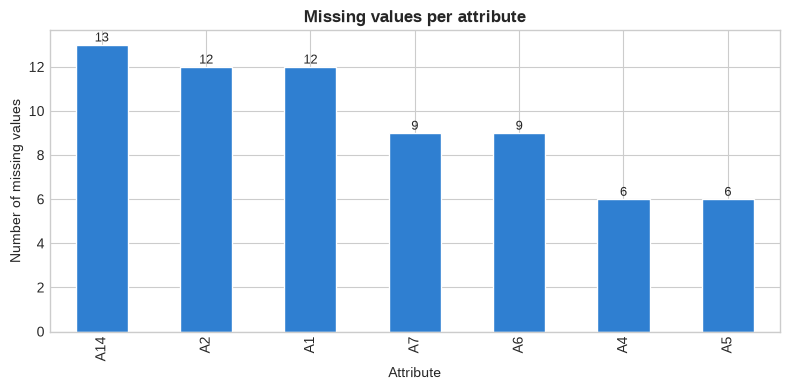

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_summary["missing_count"].plot(kind="bar", ax=ax, color=PALETTE[0], edgecolor="white")
ax.set_title("Missing values per attribute")
ax.set_ylabel("Number of missing values")
ax.set_xlabel("Attribute")
for i, v in enumerate(missing_summary["missing_count"]):
    ax.text(i, v + 0.15, str(int(v)), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

> **Insight:** this confirms what the dataset documentation states — **37 records (5%)**
have at least one missing value, spread across A1, A2, A4, A5, A6, A7 and A14.

### 3.3 Target class distribution

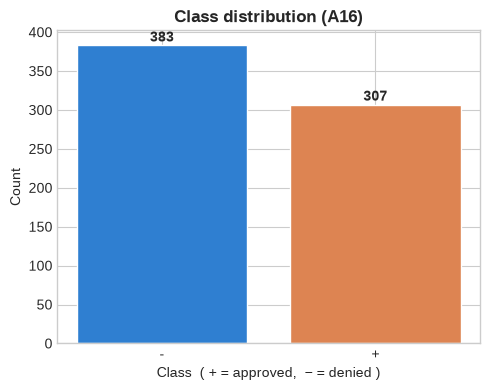

A16
-    0.555
+    0.445
Name: proportion, dtype: float64

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["A16"].value_counts()
ax.bar(counts.index.astype(str), counts.values, color=[PALETTE[0], PALETTE[1]], edgecolor="white")
ax.set_title("Class distribution (A16)")
ax.set_xlabel("Class  ( + = approved,  − = denied )")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

df["A16"].value_counts(normalize=True).round(3)

### 3.4 Distribution of continuous attributes

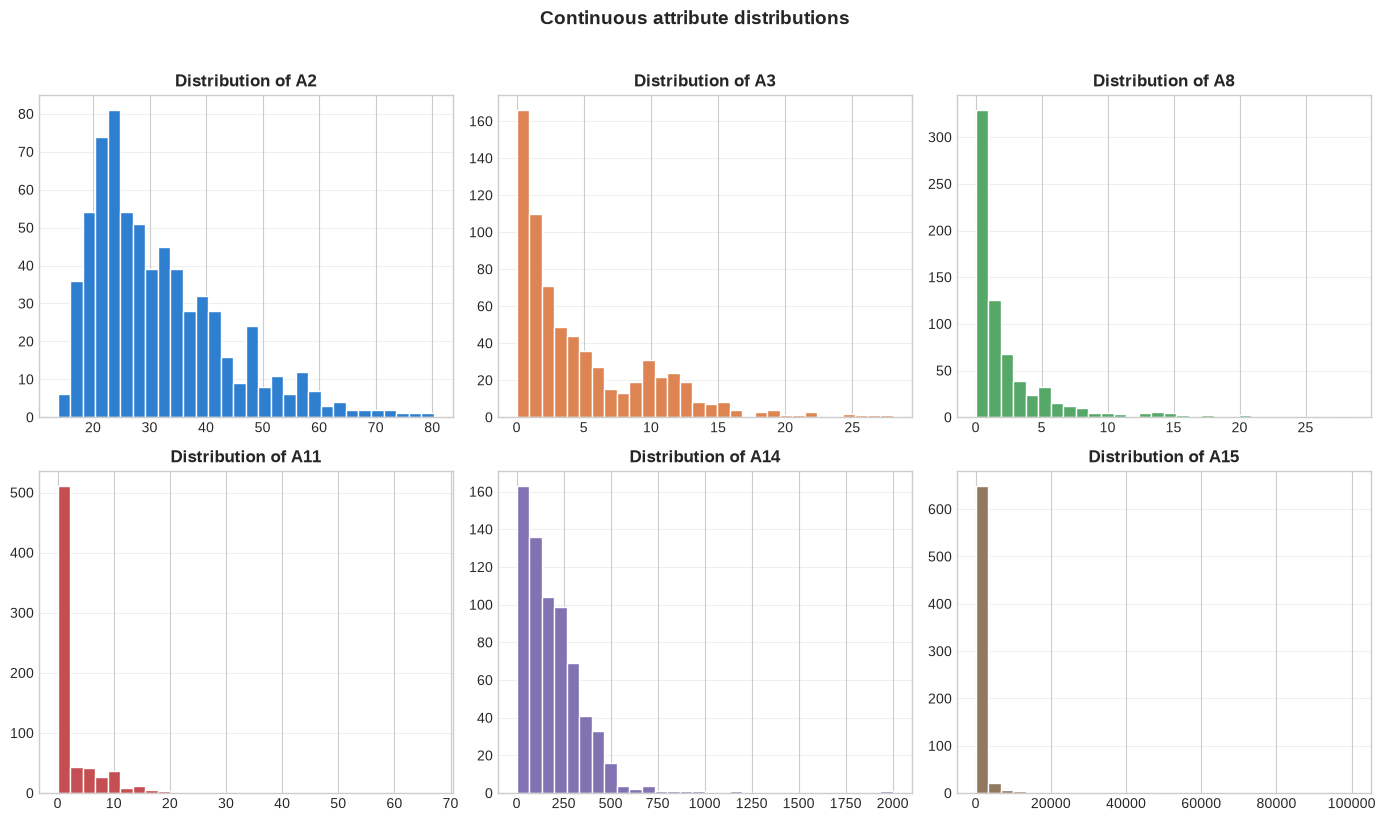

In [10]:
continuous_cols = ["A2", "A3", "A8", "A11", "A14", "A15"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, ax, c in zip(continuous_cols, axes.ravel(), PALETTE):
    df[col].hist(bins=30, ax=ax, color=c, edgecolor="white")
    ax.set_title(f"Distribution of {col}")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Continuous attribute distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Outlier detection (boxplots + IQR rule)

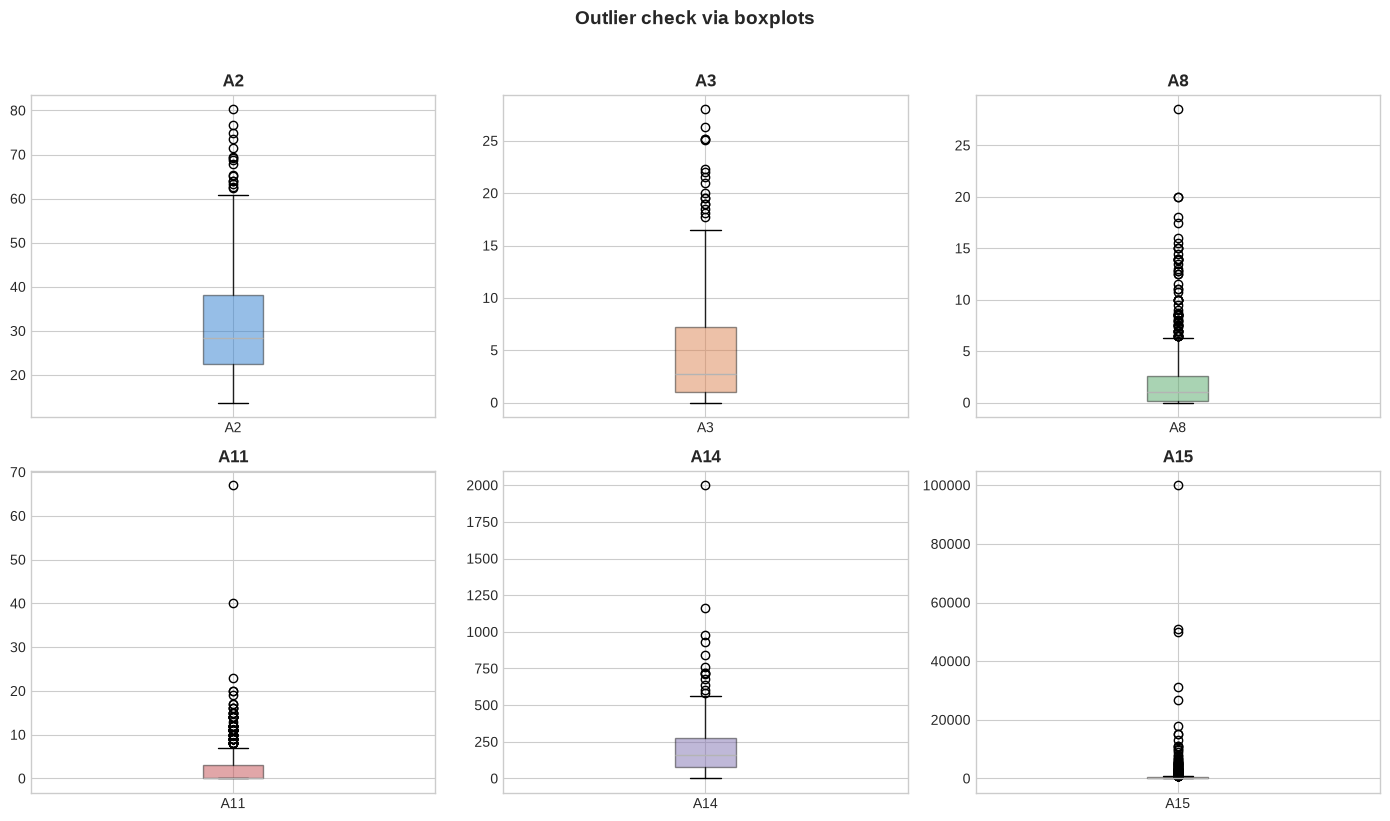

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, ax, c in zip(continuous_cols, axes.ravel(), PALETTE):
    bp = df.boxplot(column=col, ax=ax, patch_artist=True, return_type="dict")
    for box in bp["boxes"]:
        box.set(facecolor=c, alpha=0.5)
    ax.set_title(col)
fig.suptitle("Outlier check via boxplots", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = {c: iqr_outlier_count(df[c].dropna()) for c in continuous_cols}
pd.Series(outlier_counts, name="outlier_count (IQR rule)").sort_values(ascending=False).to_frame()\
    .style.background_gradient(cmap="Oranges")

,outlier_count (IQR rule)
A15,113
A11,79
A8,63
A3,17
A2,16
A14,13


### 3.6 Categorical attribute distributions

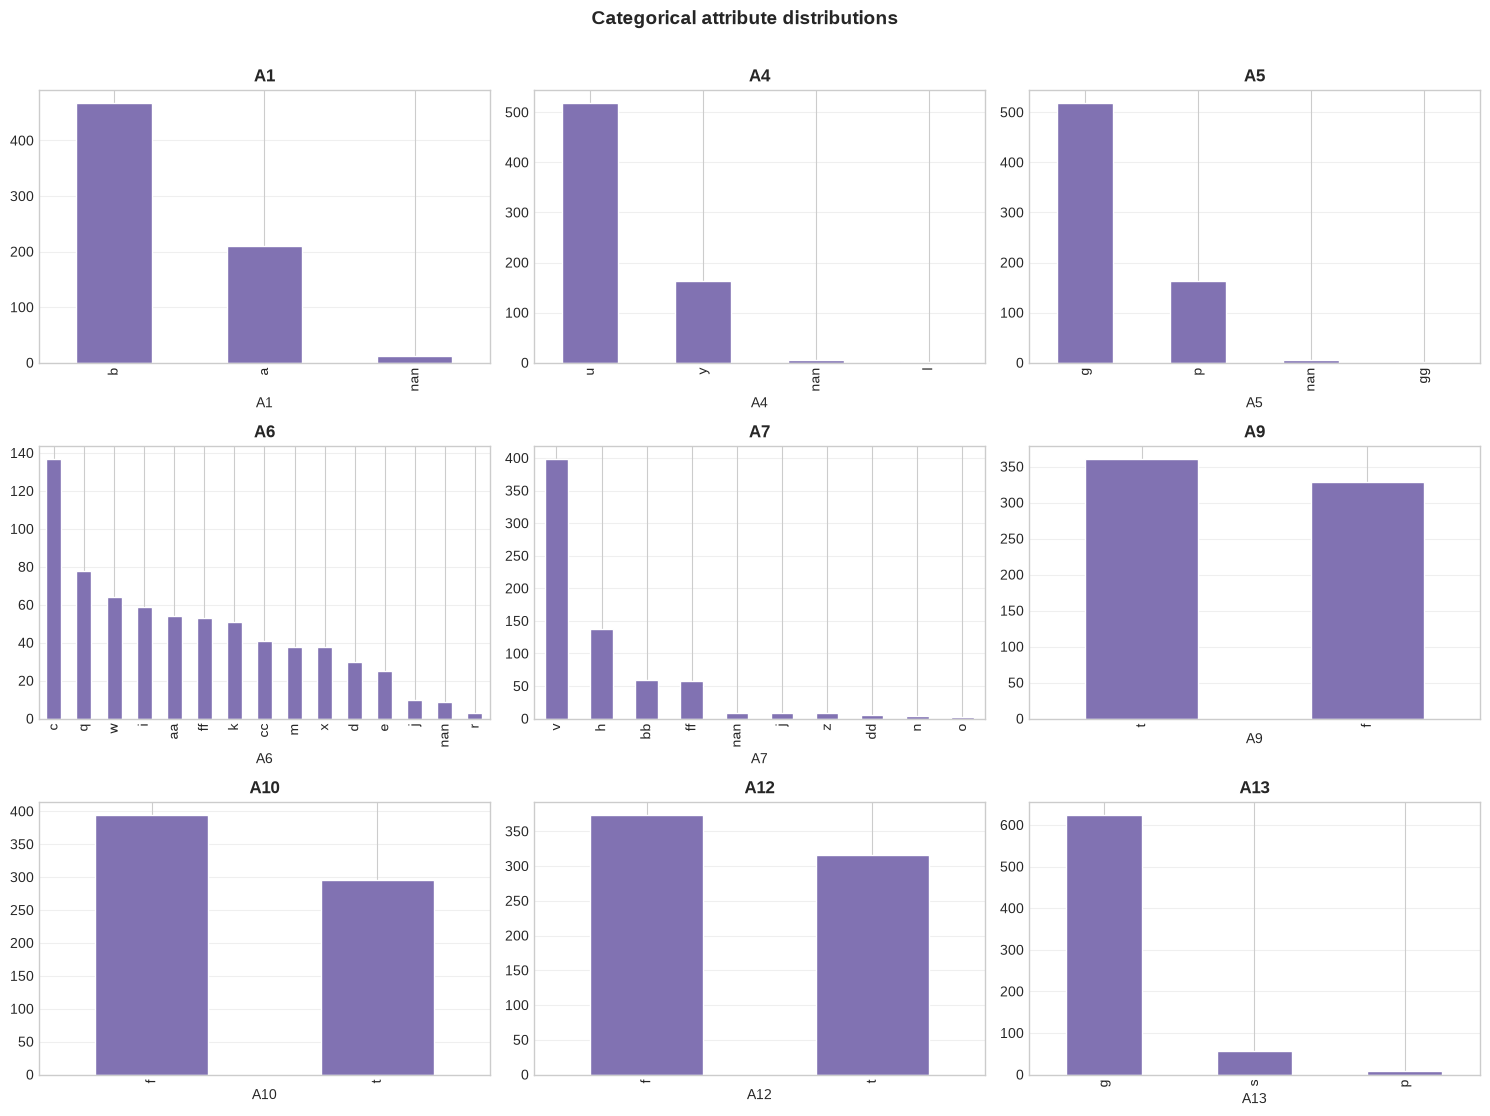

In [13]:
categorical_cols = ["A1", "A4", "A5", "A6", "A7", "A9", "A10", "A12", "A13"]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for col, ax in zip(categorical_cols, axes.ravel()):
    df[col].value_counts(dropna=False).plot(kind="bar", ax=ax, color=PALETTE[4], edgecolor="white")
    ax.set_title(col)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Categorical attribute distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()